In [68]:
import pandas as pd


In [69]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df

,ds,Airports,Class,y
0,1989-07-10,ADL-PER,Business,193
1,1989-07-17,ADL-PER,Business,254
2,1989-07-24,ADL-PER,Business,185
3,1989-07-31,ADL-PER,Business,254
4,1989-08-07,ADL-PER,Business,191
...,...,...,...,...
7402,1992-10-19,SYD-PER,First,203
7403,1992-10-26,SYD-PER,First,137
7404,1992-11-02,SYD-PER,First,161
7405,1992-11-09,SYD-PER,First,155


## 3 way to change column type 
### first way:


In [70]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv", parse_dates=["ds"])
print(df["ds"].dtype)

datetime64[ns]


### second way:

In [71]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df_test["ds"] = pd.to_datetime(df_test["ds"] , format = "%Y-%M-%d")
print(df_test["ds"].dtype)

datetime64[ns]


### third way: custom parser

In [72]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"] , date_format = "%Y-%m-%d")
print(df_test["ds"].dtype)

datetime64[ns]


In [73]:
melsyd_economy = (
    pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
).reset_index().drop(columns = ["index"])

melsyd_economy

,ds,unique_id,Class,y
0,1987-06-22,MEL-SYD,Economy,20.167
1,1987-06-29,MEL-SYD,Economy,20.161
2,1987-07-06,MEL-SYD,Economy,19.993
3,1987-07-13,MEL-SYD,Economy,20.986
4,1987-07-20,MEL-SYD,Economy,20.497
...,...,...,...,...
277,1992-10-19,MEL-SYD,Economy,28.837
278,1992-10-26,MEL-SYD,Economy,26.548
279,1992-11-02,MEL-SYD,Economy,27.279
280,1992-11-09,MEL-SYD,Economy,27.306


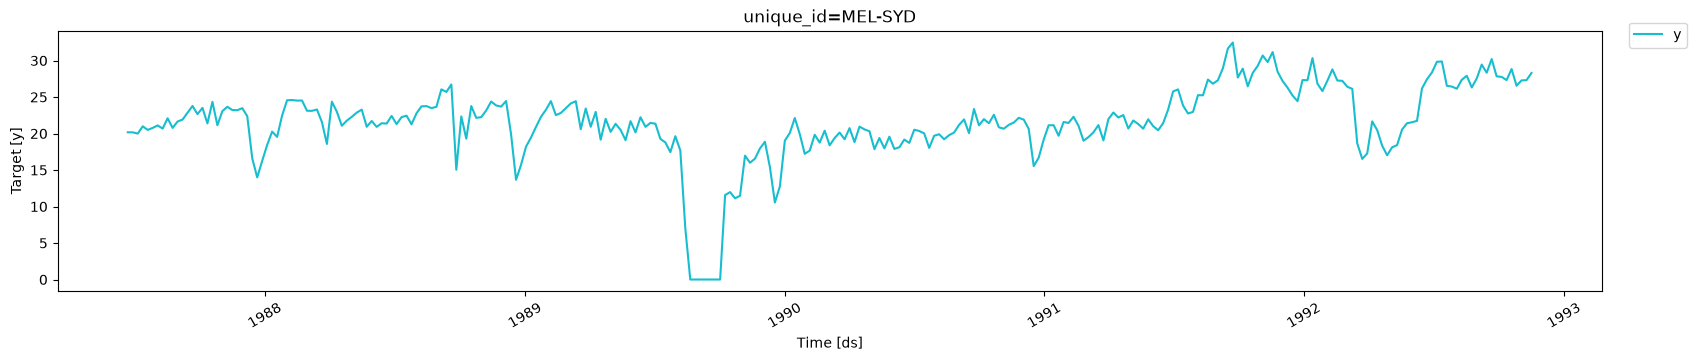

In [74]:
from utilsforecast.plotting import plot_series

plot_series(
    df = melsyd_economy,
    id_col = "unique_id",
    time_col = "ds",
    target_col = "y")



In [75]:
pbs = (
    pd.read_csv("C:\\Users\\dell\\forecasting\\PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


In [76]:
total_cost = (pbs
              .loc[pbs["ATC2"] == "A10"]
              .drop(columns= ["ATC1" , "ATC2"])
              .groupby("Month" , as_index=False)
              .agg({"Cost" : "sum"})
              .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
              .rename(columns= {"Cost" : "Total cost (milions)"})
)

total_cost

,Month,Total cost (milions)
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


| code |  meaning  | example |
|------|-----------|---------|
| %b  | abbreviated month name | Jan |
| %B  | Full month name | January |
| %m  | Month number | 01 ,02 |
| %Y  | 4 digit year | 2026 |
| %y  | 2 digit year | 26 |
| %d  | day of month | 01 ,02 |
| %a | abbreviated weekday name | Mon |
| %A | Full weekday name | Monday |


In [77]:
df = total_cost.assign(
    Month_name = total_cost["Month"].dt.strftime("%b"),
    Year = total_cost["Month"].dt.year,
    Month_num = total_cost["Month"].dt.month
)
df

,Month,Total cost (milions),Month_name,Year,Month_num
0,1991-07-01,3.53,Jul,1991,7
1,1991-08-01,3.18,Aug,1991,8
2,1991-09-01,3.25,Sep,1991,9
3,1991-10-01,3.61,Oct,1991,10
4,1991-11-01,3.57,Nov,1991,11
...,...,...,...,...,...
199,2008-02-01,21.65,Feb,2008,2
200,2008-03-01,18.26,Mar,2008,3
201,2008-04-01,23.11,Apr,2008,4
202,2008-05-01,22.91,May,2008,5


In [78]:
unique_years = df["Year"].unique()
unique_years

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008], dtype=int32)

In [79]:
import seaborn as sns

year_palette = sns.color_palette("husl", n_colors=len(unique_years))

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\958864624.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


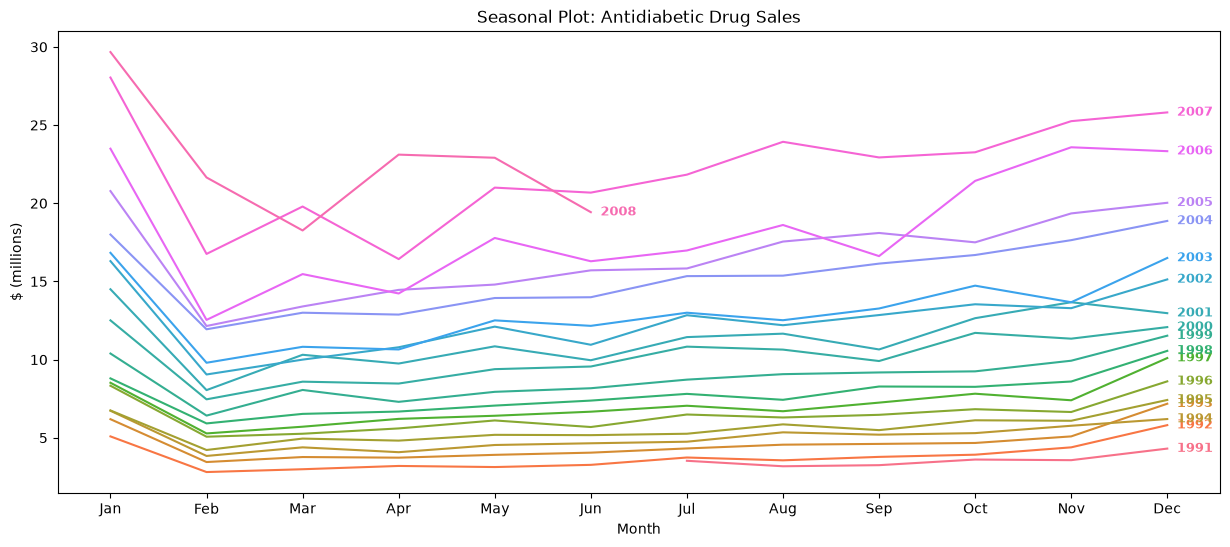

In [80]:
import seaborn as sns
import matplotlib.pylab as plt 

fig , ax = plt.subplots(figsize=(15, 6))
sns.lineplot( data= df , x="Month_num", y="Total cost (milions)" ,hue= "Year" , palette= year_palette ,legend= False , ax= ax )

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ],
)

min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Total cost (milions)"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year), ha="left", va="center", fontsize=9, weight="bold", color=color)

fig.show()


In [81]:
vic_elc_df = pd.read_csv("C:\\Users\\dell\\forecasting\\vic_elec.csv",parse_dates=["ds"])
vic_elc_df

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
105199,2014-12-31 21:30:00,Temperature,19.000000,False
105200,2014-12-31 22:00:00,Temperature,18.500000,False
105201,2014-12-31 22:30:00,Temperature,17.700000,False
105202,2014-12-31 23:00:00,Temperature,17.300000,False


In [82]:
vic_elc_demand = vic_elc_df[vic_elc_df["unique_id"] == "Demand"]
vic_elc_demand

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.448714,False
52598,2014-12-31 22:00:00,Demand,3791.637322,False
52599,2014-12-31 22:30:00,Demand,3724.835666,False
52600,2014-12-31 23:00:00,Demand,3761.886854,False


C:\Users\dell\AppData\Local\Temp\ipykernel_20976\3415217878.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


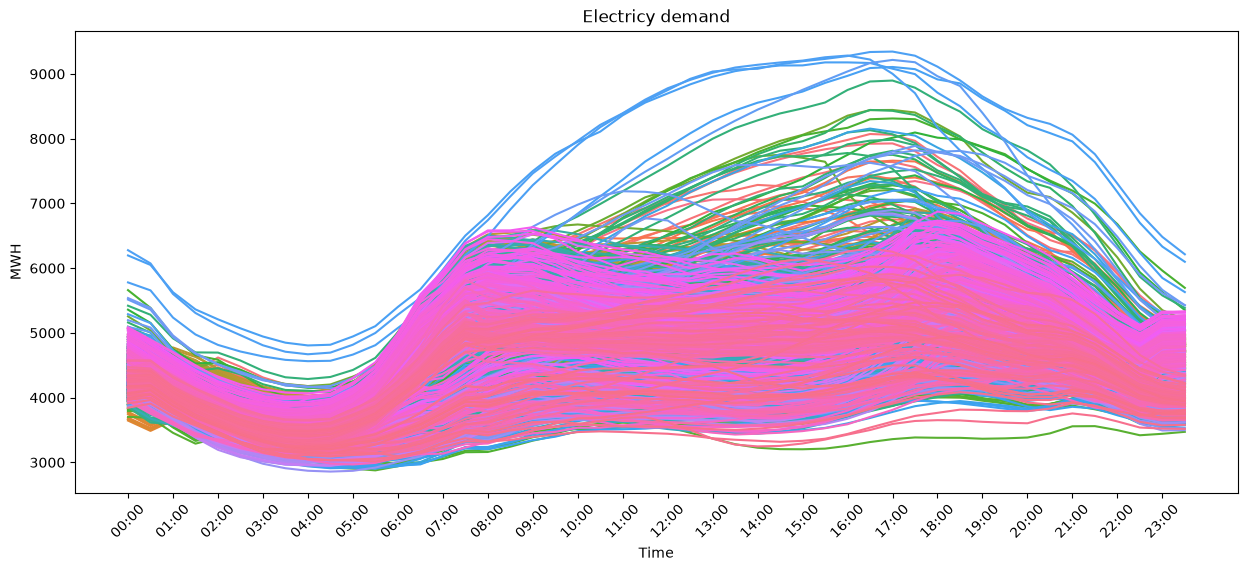

In [83]:
import seaborn as sns

df = vic_elc_demand.assign(
    hour_min = lambda x : x["ds"].dt.strftime("%H:%M"),
    day = lambda x : x["ds"].dt.date
)

fig , ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data= df , x="hour_min" , y = "y", hue="day" , palette="husl", legend=False , ax =ax)

ax.set(title="Electricy demand",
       xlabel = "Time",
       ylabel = "MWH"
)

unique_ticks = df["hour_min"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_20976\1563768250.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


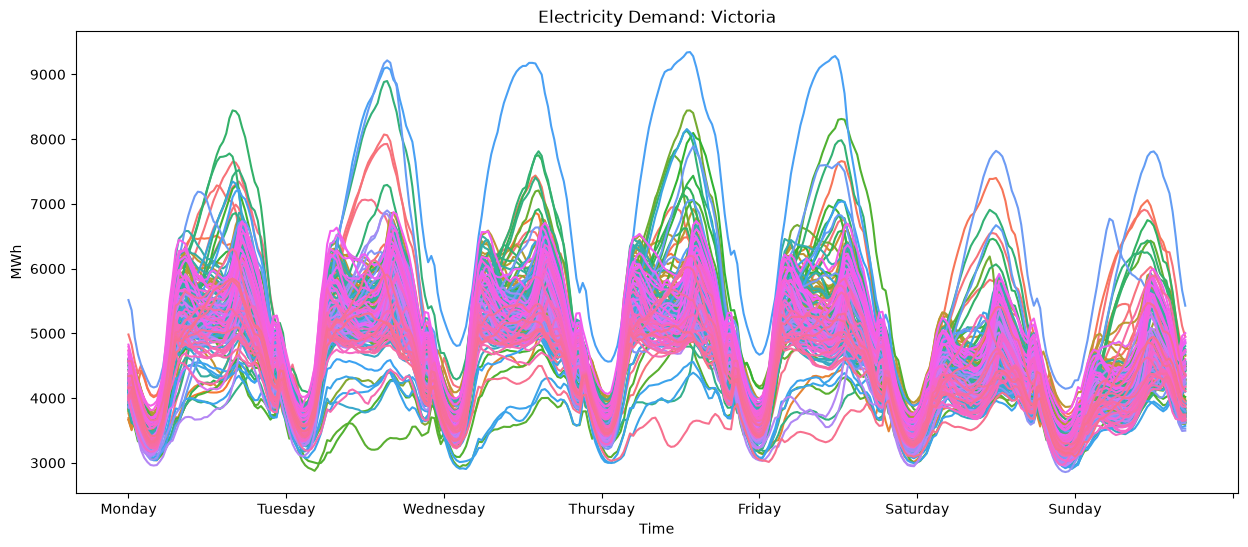

In [84]:
df = (
    vic_elc_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week=lambda x: x["ds"].dt.day_name(),
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))
 
fig, ax = plt.subplots(figsize = (15,6))

for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",ax=ax, color=color_map[week])

ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\3084811638.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


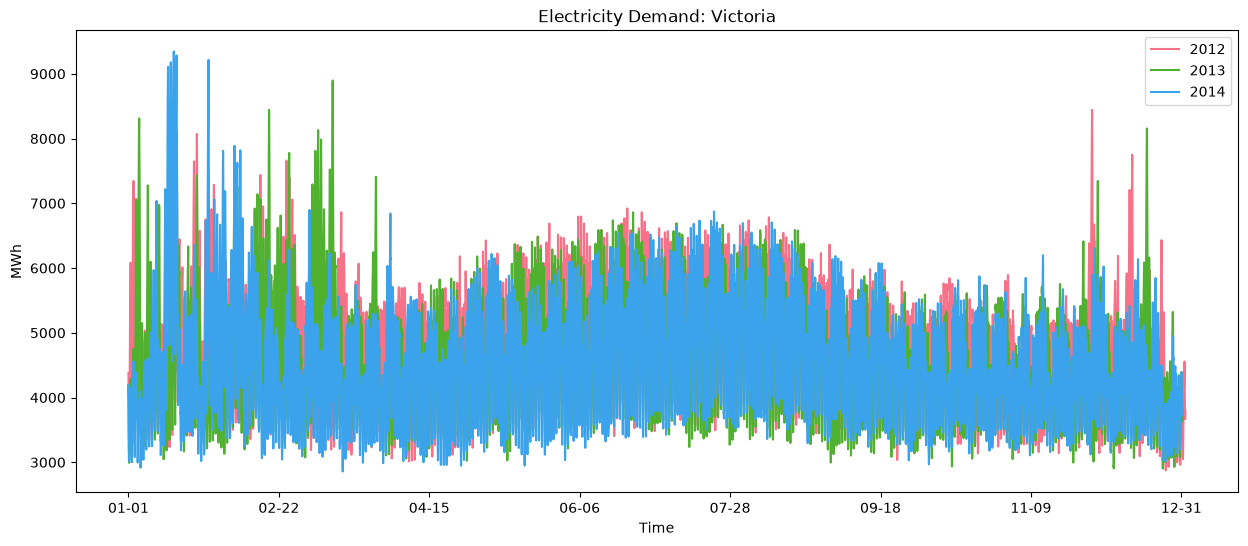

In [85]:
df = vic_elc_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)
palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots(figsize = (15,6))

for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax, label=str(year), color=palette[i_year])
    
ax.set(title="Electricity Demand: Victoria", ylabel="MWh", xlabel="Time")
fig.show()

In [86]:
total_cost

,Month,Total cost (milions)
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


C:\Users\dell\AppData\Local\Temp\ipykernel_20976\2395569505.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


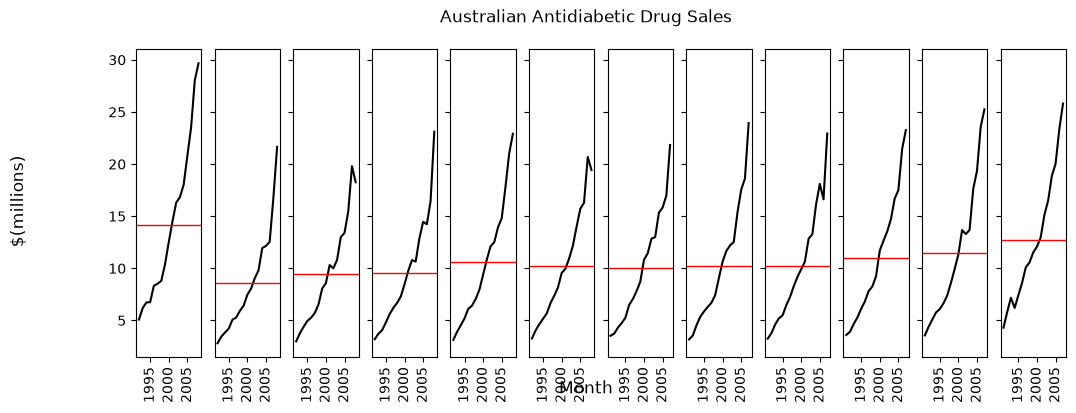

In [87]:
df = total_cost.assign(
    year=total_cost["Month"].dt.year,
    month_name=total_cost["Month"].dt.month_name(),
    month_idx=total_cost["Month"].dt.month)

fig, axes = plt.subplots(1, 12, figsize=(12,4), sharey=True)
for ax, ((_, month_name), month_df) in zip(axes, df.groupby(["month_idx", "month_name"])):
    mean_cost = month_df["Total cost (milions)"].mean()
    ax.plot(month_df["year"], month_df["Total cost (milions)"], color="black")
    ax.axhline(mean_cost, color="red", linewidth=1)
    #ax.set(title=month_name[:3], xlabel="")
    ax.tick_params(axis="x", rotation=90)

fig.suptitle("Australian Antidiabetic Drug Sales")
fig.supxlabel("Month")
fig.supylabel("$(millions)")
fig.show()

In [88]:
tourism = pd.read_csv("C:\\Users\\dell\\forecasting\\tourism(1).csv", parse_dates=["ds"])
tourism

,ds,Region,State,Purpose,y
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533
...,...,...,...,...,...
24315,2016-10-01,Yorke Peninsula,South Australia,Visiting,33.672151
24316,2017-01-01,Yorke Peninsula,South Australia,Visiting,46.223014
24317,2017-04-01,Yorke Peninsula,South Australia,Visiting,50.582837
24318,2017-07-01,Yorke Peninsula,South Australia,Visiting,27.766728


C:\Users\dell\AppData\Local\Temp\ipykernel_20976\1343844545.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


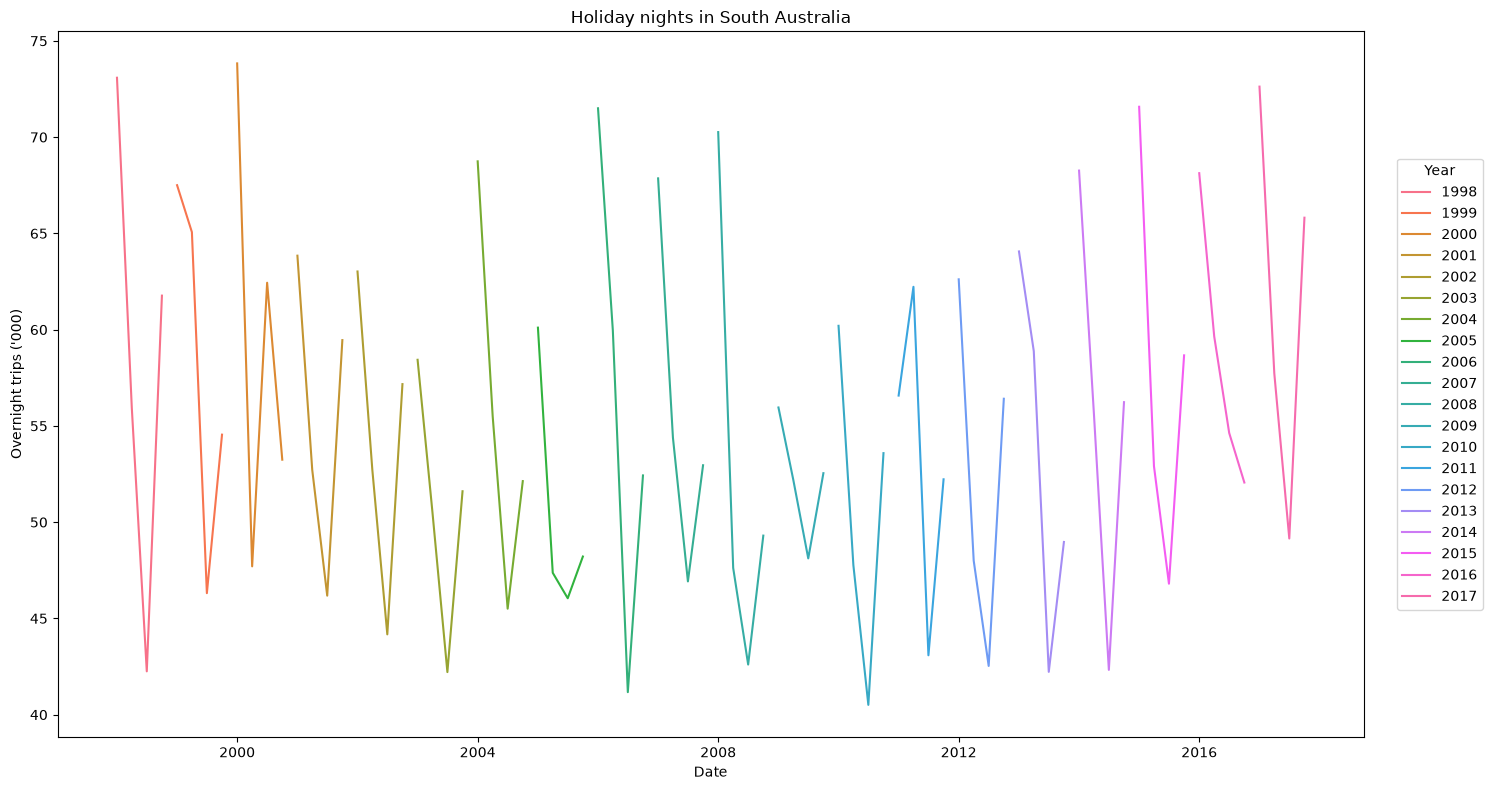

In [89]:
trip2 = (tourism
        .loc[lambda x : (x["State"] == "South Australia") & (x["Purpose"]== "Holiday")]
        .groupby(["ds"] , as_index = False)
        .agg({"y" : "mean"})
        )
trip2
df = trip2.assign(
    Year = trip2["ds"].dt.year
)

fig , ax = plt.subplots(figsize=(15, 8))
unique_years = df.Year.nunique()
palette = sns.color_palette("husl" , n_colors= unique_years)
sns.lineplot(data=df , x= "ds" , y = "y" , hue="Year" , palette=palette, ax=ax)

ax.set(
    title = "Holiday nights in South Australia",
    ylabel = "Overnight trips ('000)",
    xlabel = "Date"
)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Year")
plt.tight_layout()
fig.show()

In [90]:
tourism["Purpose"].unique()

array(['Business', 'Holiday', 'Other', 'Visiting'], dtype=object)

In [91]:
trips = (tourism.loc[lambda x : x["Purpose"] == "Holiday"]
            .groupby(["State", "ds"], as_index=False)
            .agg({"y" : "sum"})
        )
trips

,State,ds,y
0,ACT,1998-01-01,196.218550
1,ACT,1998-04-01,126.770597
2,ACT,1998-07-01,110.679645
3,ACT,1998-10-01,170.472206
4,ACT,1999-01-01,107.779245
...,...,...,...
635,Western Australia,2016-10-01,982.752589
636,Western Australia,2017-01-01,1134.352019
637,Western Australia,2017-04-01,997.852225
638,Western Australia,2017-07-01,879.988533


C:\Users\dell\AppData\Local\Temp\ipykernel_20976\827983028.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


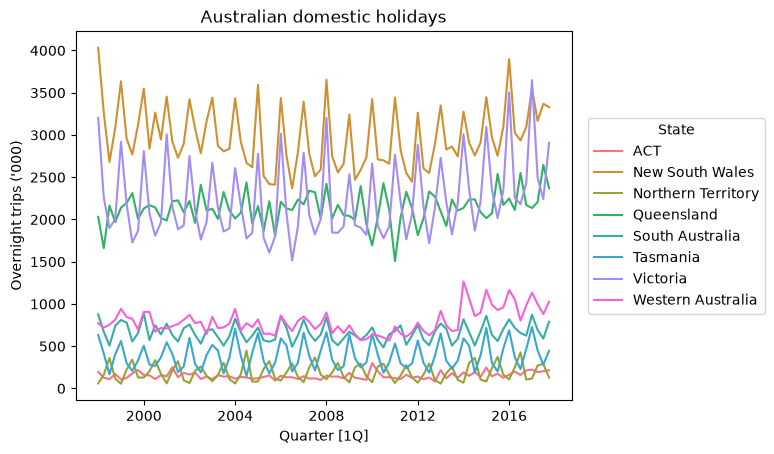

In [92]:
fig , ax = plt.subplots()
palette = sns.color_palette("husl" , trips["State"].nunique())
sns.lineplot(data=trips ,x="ds" , y="y" ,hue="State" , palette=palette)
ax.set(
    title = "Australian domestic holidays",
    ylabel = "Overnight trips ('000)",
    xlabel = "Quarter [1Q]"
)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="State")
fig.show()

**.dt.quarter** -> شماره فصل را برمی‌گرداند:

    ژانویه تا مارس → 1
    آوریل تا ژوئن → 2
    ژوئیه تا سپتامبر → 3
    اکتبر تا دسامبر → 4

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\3095139149.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


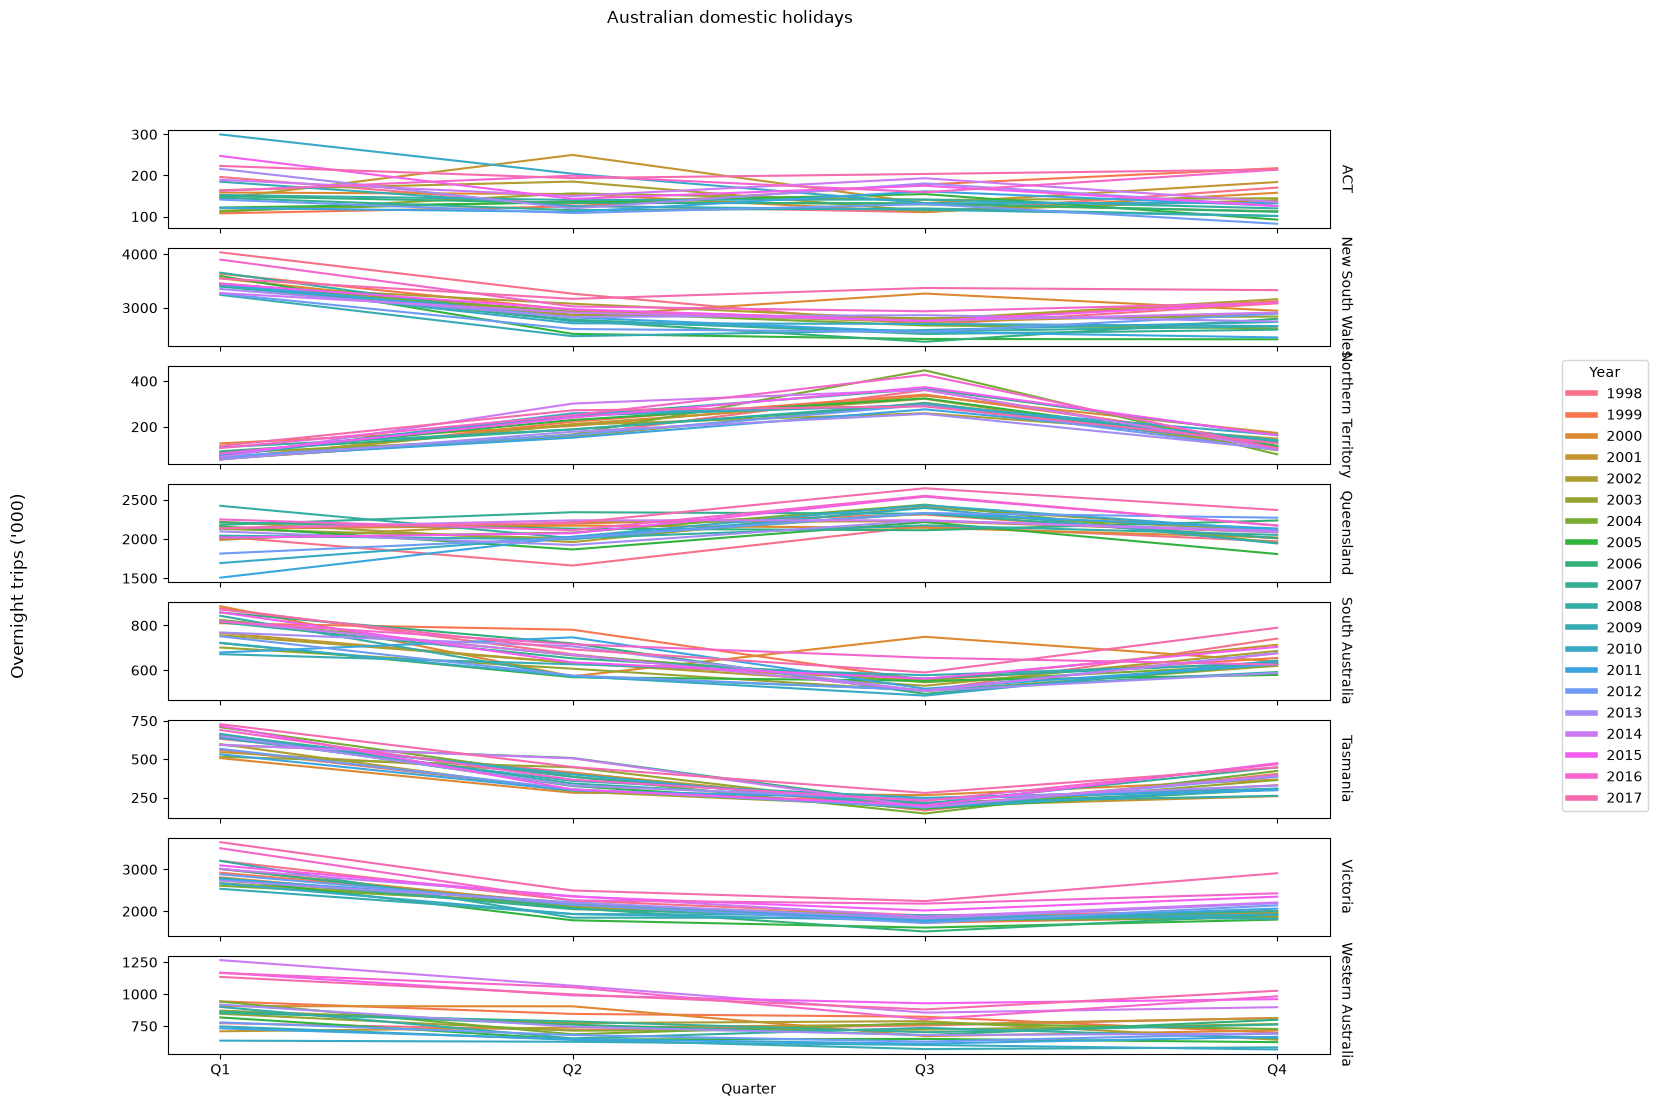

In [93]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)

num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)   #what is input of palette? -> RBG tuples 
fig, axes = plt.subplots(num_states, sharex=True, figsize=(15, 12))

for ax, (state, state_df) in zip(axes, df.groupby("State")):
    sns.lineplot(data=state_df, x="Quarter", y="y",hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,size="medium", transform=ax.transAxes)
    # va = vertical alignment in center
    # ha = horizontal alignment -> the right side of text x = 1.02

handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)

fig.legend(handles, labels, title="Year", loc="center left",bbox_to_anchor=(1.05, 0.5))
fig.suptitle("Australian domestic holidays")
fig.supylabel("Overnight trips ('000)")
fig.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\2003333617.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


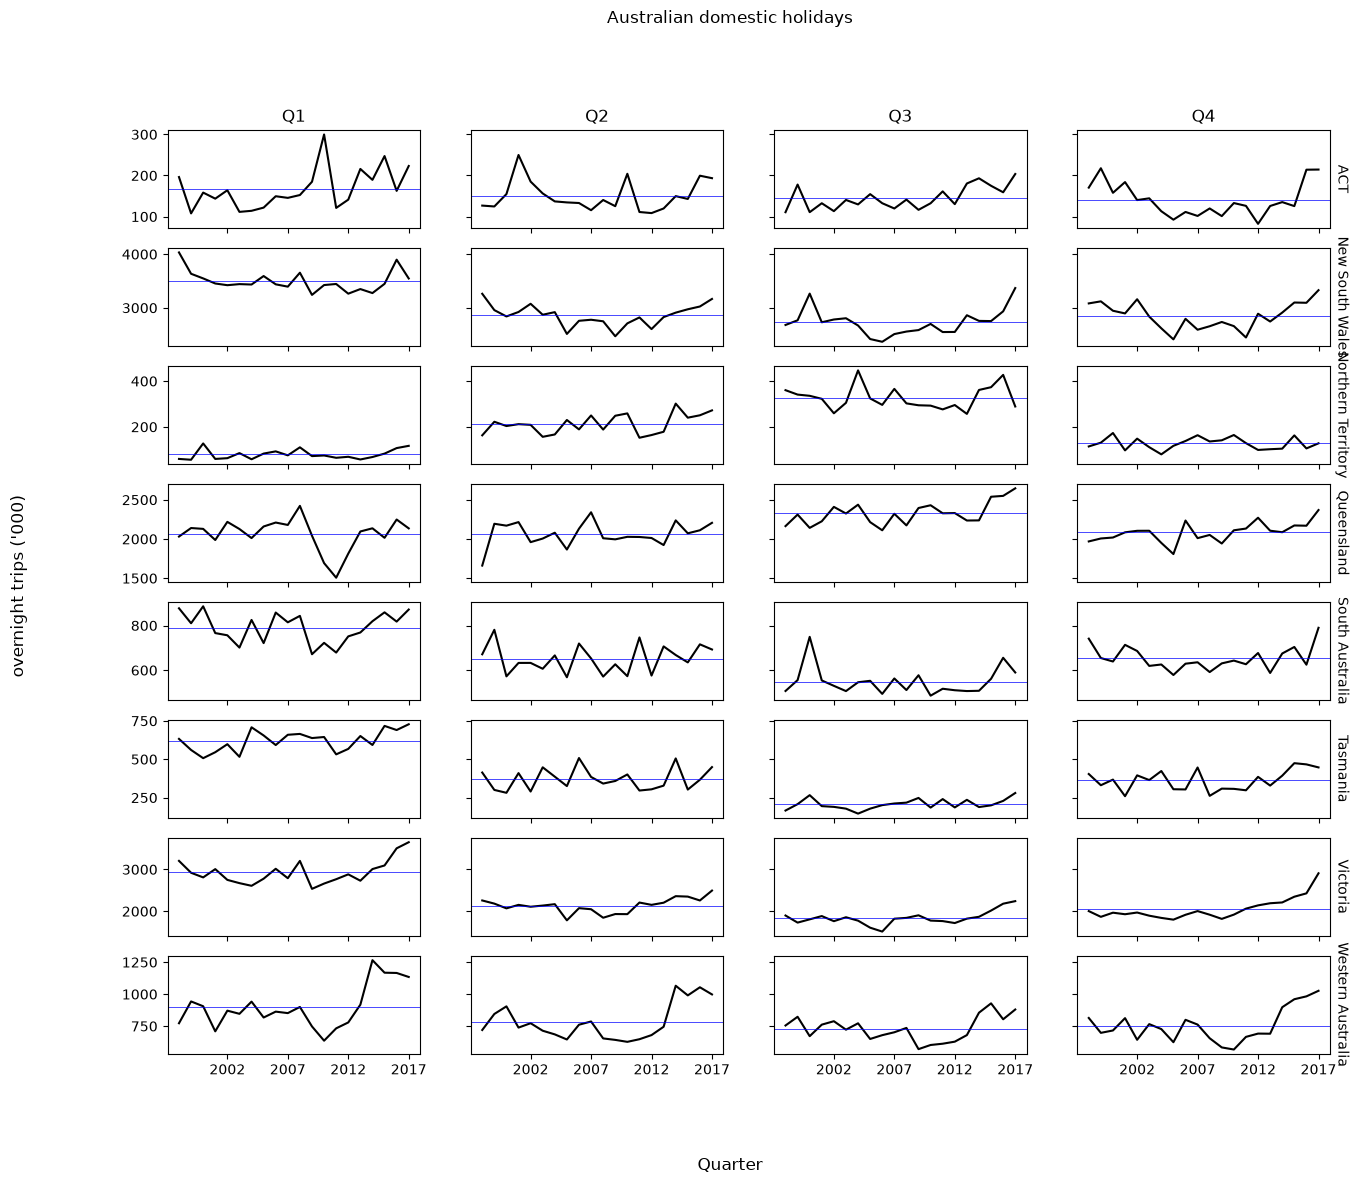

In [94]:
fig , axes = plt.subplots(num_states, 4 , sharex= True, sharey="row" , figsize = (15,12))

for ax, ((state , quarter),sq_df) in zip(axes.flat , df.groupby(["State" , "Quarter"])):
    ax.plot(sq_df["Year"] , sq_df["y"] , color= "Black")
    ax.axhline(sq_df["y"].mean() , color="Blue" , linewidth = 0.5)
    xticks = sq_df["Year"].loc[lambda x : (x % 5) == 2]

    if ax in axes[0]:
        ax.set(title=quarter , xticks = xticks)
    if ax in axes[: , -1]:
        ax.text(1.02 , 0.5, state , va = "center" , ha = "left" , rotation = 270, size = "medium",transform=ax.transAxes)

fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("overnight trips ('000)")
fig.show()


In [99]:
vic_elc_df

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
105199,2014-12-31 21:30:00,Temperature,19.000000,False
105200,2014-12-31 22:00:00,Temperature,18.500000,False
105201,2014-12-31 22:30:00,Temperature,17.700000,False
105202,2014-12-31 23:00:00,Temperature,17.300000,False


In [100]:
vic_elc_demand

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.448714,False
52598,2014-12-31 22:00:00,Demand,3791.637322,False
52599,2014-12-31 22:30:00,Demand,3724.835666,False
52600,2014-12-31 23:00:00,Demand,3761.886854,False


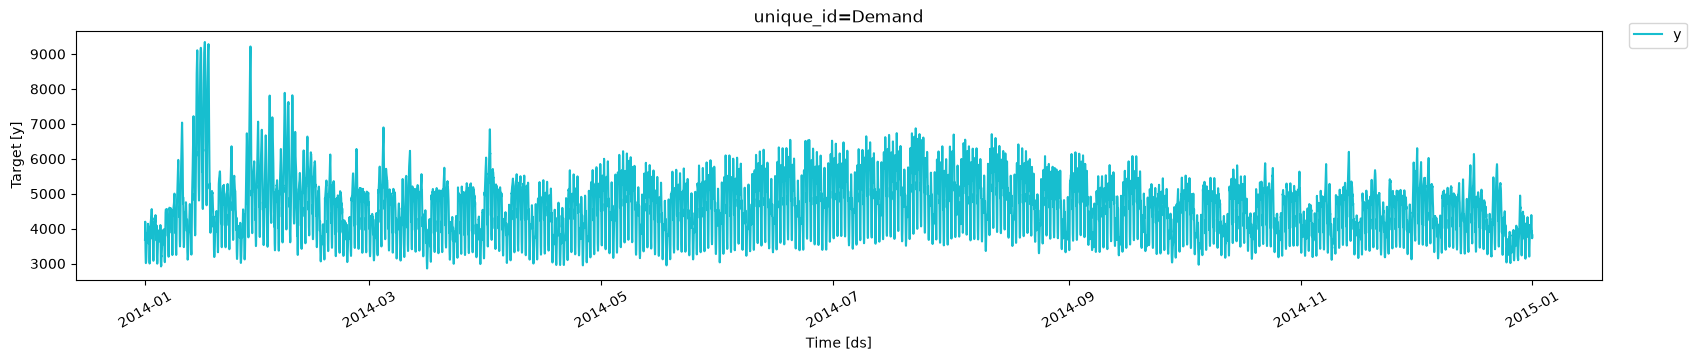

In [ ]:
plot_series(vic_elc_df, ids=["Demand"],max_insample_length=2 * 24 * 365)

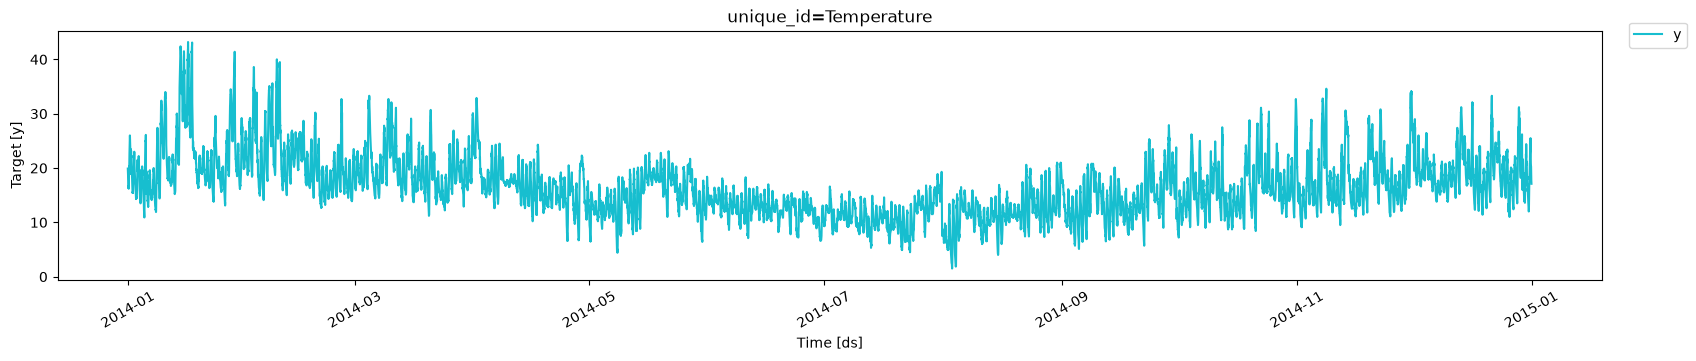

In [102]:
plot_series(vic_elc_df , ids=["Temperature"] , max_insample_length=2 * 24 * 365,)

C:\Users\dell\AppData\Local\Temp\ipykernel_20976\3499765145.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


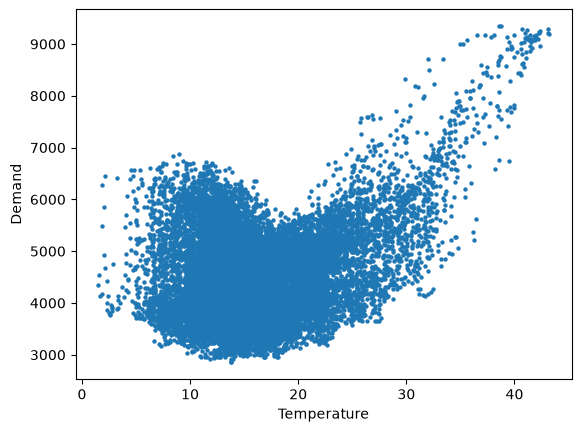

In [103]:
elc = (vic_elc_df
        .loc[lambda x :x["ds"].dt.year == 2014]
        .pivot(index ="ds" , columns ="unique_id" , values ="y")
        .reset_index()
)

fig , ax = plt.subplots()
sns.scatterplot(data=elc , x="Temperature" , y="Demand" , ax=ax , linewidth = 0 , s = 10 , legend=False)

fig.show()

